# Climate Analysis for Study Regions and Ecological Applications

This notebook summarizes and analyzes climate conditions across the main study areas and ecological datasets.

### Spatial Scales
- **Regional:** Eastern Morocco vs. Tata
- **Focal areas:** Bouarfa vs. Al Baten
- **Field-associated:** Climate conditions linked to vegetation surveys, trophic sites, and habitat classes

### Climate Datasets
- **TerraClimate**
- **CHIRPS**
- **ERA5-Land**
- **WorldClim**

### Analysis Periods
Climate data are generally considered from **2000–present**, with subsets matched to specific research datasets:

- **Movement ecology:** ~2008–present
- **Vegetation monitoring:** ~2007/2016–present
- **Long-term climate reference:** 1991–2020

Analyses may include **monthly, seasonal, calendar-year, and ecological-year** summaries depending on the research question.


* All climate pre-processing, summary, classification, and plotting functions are now organized in a separate Python module (**`climate_analysis.py`**). The functions can be imported and called directly from this notebook, which keeps the notebook cleaner and avoids repeating the same code for different datasets, spatial scales, or baseline periods.


- **WMO/World Meteorological Organization** defines climate normals using **30-year periods**, with **1991–2020** as the current standard normal, because shorter periods are more sensitive to natural interannual variability—especially important for precipitation in an arid system like Morocco.

- 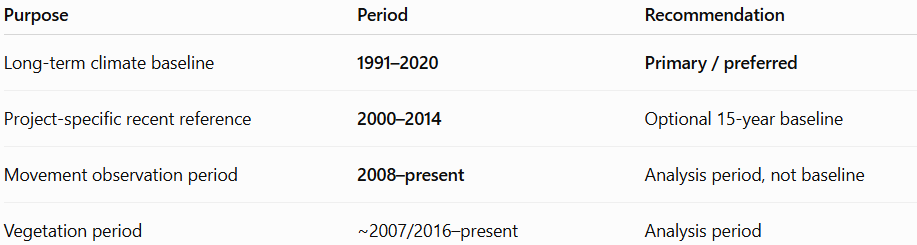

## 1. GEE download and extraction
- **Regional:** Eastern Morocco vs. Tata
- **Focal areas:** Bouarfa vs. Al Baten
- **TerraClimate** and **ERA5-Land**


In [4]:
from google.auth import compute_engine
import ee
print(ee.__version__)
import os

import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium

0.1.370


In [6]:
import ee
import datetime

# ======================================================
# 0. Initialize Earth Engine
# ======================================================
# Trigger the authentication flow.
# ee.Authenticate()

# Initialize the library.
ee.Initialize(project='rse-global-wetlands') # this is the esential step!

Enter verification code:  4/1ATsMZqArl46UleWOwiCy6Zy6VnWfv3Q2Fwi87cWgeUnc8po9XUkPdOcoraA



Successfully saved authorization token.


### 1.2 Build-in py module

In [41]:
from gee_climate_export import run_climate_export
task, climate_areas, availability = run_climate_export(
    start_date="1991-01-01"
)

GEE Climate Export
Requested start date: 1991-01-01
Requested end date:   latest available
Datasets:             TerraClimate, ERA5-Land

Dataset availability:
TerraClimate: 408 monthly images | 1991-01 to 2024-12
ERA5-Land: 427 monthly images | 1991-01 to 2026-07

Preparing: TerraClimate | Regional | Eastern Morocco
Preparing: TerraClimate | Regional | Tata
Preparing: TerraClimate | Focal | Al Baten
Preparing: TerraClimate | Focal | Bouarfa
Preparing: ERA5-Land | Regional | Eastern Morocco
Preparing: ERA5-Land | Regional | Tata
Preparing: ERA5-Land | Focal | Al Baten
Preparing: ERA5-Land | Focal | Bouarfa

Total output records: 3340

Export started.
Google Drive folder: GEE_Clim_exports
Output file prefix:  All_Climate_Areas_Monthly_1991_Present
Check the Earth Engine Tasks tab.


In [ ]:
# TerraClimate only
task, climate_areas, availability = run_climate_export(
    start_date="1991-01-01",
    datasets=("TerraClimate",)
)

### 1.1 Step by step functions
- now thses functions have been complied to 'gee_climate_export.py'

In [7]:
# # ======================================================
# # 1. Assets (AOIs & stations)
# # ======================================================
# Tata_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area')
# Eastern_AREA = ee.FeatureCollection('projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area')
# Bouarfa = ee.FeatureCollection('projects/rse-global-wetlands/assets/Bouarfa_study_area')
# AI_Baten = ee.FeatureCollection('projects/rse-global-wetlands/assets/Al_Baten_study_area')
# stations = ee.FeatureCollection('projects/rse-global-wetlands/assets/Trophic_survey_data_114_station_habitat')
# OUT_FOLDER = 'GEE_Clim_exports'

# ======================================================
# 1. Configuration
# ======================================================
START_DATE = "2000-01-01"

# filterDate() uses an exclusive end date,
# so add one day to include everything currently available.
END_DATE = (
    datetime.date.today() + datetime.timedelta(days=1)
).strftime("%Y-%m-%d")

OUT_FOLDER = "GEE_Clim_exports"


# ======================================================
# 2. Study areas
# ======================================================

# ---------- Regional ----------
Eastern_AREA = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area"
)

Tata_AREA = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/Tata_Morocco_Working_Area"
)

# ---------- Focal ----------
# Replace these two with your actual GEE asset IDs
Al_Baten_AREA = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/Al_Baten_study_area"
)

Bouarfa_AREA = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/Bouarfa_study_area"
)


# Organize all study areas in one dictionary
AOIS = {
    "Eastern Morocco": {
        "fc": Eastern_AREA,
        "spatial_level": "Regional"
    },
    "Tata": {
        "fc": Tata_AREA,
        "spatial_level": "Regional"
    },
    "Al Baten": {
        "fc": Al_Baten_AREA,
        "spatial_level": "Focal"
    },
    "Bouarfa": {
        "fc": Bouarfa_AREA,
        "spatial_level": "Focal"
    }
}


# ======================================================
# 3. Climate datasets
# ======================================================

# ------------------------------------------------------
# A. ERA5-Land Monthly
# ------------------------------------------------------
# GEE:
# ECMWF/ERA5_LAND/MONTHLY_AGGR
#
# temperature_2m             K
# total_precipitation_sum    m
# ------------------------------------------------------

def process_era5_land(img):

    temp_c = (
        img.select("temperature_2m")
        .subtract(273.15)
        .rename("temp_C")
    )

    precip = img.select("total_precipitation_sum")

    # Occasionally ERA5-Land contains very small negative
    # precipitation values because of data packing.
    precip = precip.where(precip.lt(0), 0)

    precip_mm = (
        precip
        .multiply(1000)
        .rename("precip_mm")
    )

    return (
        temp_c
        .addBands(precip_mm)
        .copyProperties(img, ["system:time_start"])
    )


era5_land = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterDate(START_DATE, END_DATE)
    .map(process_era5_land)
)


# ------------------------------------------------------
# B. TerraClimate Monthly
# ------------------------------------------------------
# GEE:
# IDAHO_EPSCOR/TERRACLIMATE
#
# tmmx     maximum temperature, scale = 0.1
# tmmn     minimum temperature, scale = 0.1
# pr       precipitation, mm
#
# Mean monthly temperature is approximated as:
# (Tmax + Tmin) / 2
# ------------------------------------------------------

def process_terraclimate(img):

    tmax_c = (
        img.select("tmmx")
        .multiply(0.1)
    )

    tmin_c = (
        img.select("tmmn")
        .multiply(0.1)
    )

    temp_c = (
        tmax_c
        .add(tmin_c)
        .divide(2)
        .rename("temp_C")
    )

    precip_mm = (
        img.select("pr")
        .rename("precip_mm")
    )

    return (
        temp_c
        .addBands(precip_mm)
        .copyProperties(img, ["system:time_start"])
    )


terraclimate = (
    ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
    .filterDate(START_DATE, END_DATE)
    .map(process_terraclimate)
)


# ======================================================
# 4. Check dataset availability
# ======================================================

def check_collection(ic, name):

    n = ic.size().getInfo()

    first_date = (
        ee.Date(ic.aggregate_min("system:time_start"))
        .format("YYYY-MM")
        .getInfo()
    )

    last_date = (
        ee.Date(ic.aggregate_max("system:time_start"))
        .format("YYYY-MM")
        .getInfo()
    )

    print(
        f"{name}: "
        f"{n} monthly images | "
        f"{first_date} to {last_date}"
    )


check_collection(era5_land, "ERA5-Land")
check_collection(terraclimate, "TerraClimate")


# ======================================================
# 5. Area extraction function
# ======================================================

def extract_to_area(
    ic,
    area_fc,
    area_name,
    spatial_level,
    dataset,
    scale
):

    n = ic.size()
    image_list = ic.toList(n)

    indices = ee.List.sequence(
        0,
        n.subtract(1)
    )

    def per_image(i):

        img = ee.Image(
            image_list.get(i)
        )

        date = ee.Date(
            img.get("system:time_start")
        )

        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=area_fc.geometry(),
            scale=scale,
            maxPixels=1e13
        )

        return ee.Feature(
            None,
            stats
        ).set({
            "dataset": dataset,
            "spatial_level": spatial_level,
            "region": area_name,
            "date": date.format("YYYY-MM"),
            "year": date.get("year"),
            "month": date.get("month")
        })

    return ee.FeatureCollection(
        indices.map(per_image)
    )


# ======================================================
# 6. Extract all datasets × all areas
# ======================================================

DATASETS = {
    "TerraClimate": {
        "ic": terraclimate,
        "scale": 4638
    },
    "ERA5-Land": {
        "ic": era5_land,
        "scale": 11132
    }
}


climate_areas = ee.FeatureCollection([])

for dataset_name, dataset_info in DATASETS.items():

    for area_name, area_info in AOIS.items():

        print(
            f"Preparing: "
            f"{dataset_name} | "
            f"{area_info['spatial_level']} | "
            f"{area_name}"
        )

        fc = extract_to_area(
            ic=dataset_info["ic"],
            area_fc=area_info["fc"],
            area_name=area_name,
            spatial_level=area_info["spatial_level"],
            dataset=dataset_name,
            scale=dataset_info["scale"]
        )

        climate_areas = climate_areas.merge(fc)


print(
    "Total output records:",
    climate_areas.size().getInfo()
)


# ======================================================
# 7. Export one clean CSV
# ======================================================

task = ee.batch.Export.table.toDrive(
    collection=climate_areas,
    description="All_Climate_Areas_Monthly_2000_2025",
    folder=OUT_FOLDER,
    fileNamePrefix="All_Climate_Areas_Monthly_2000_2025",
    fileFormat="CSV",

    # Keep only useful columns
    selectors=[
        "dataset",
        "spatial_level",
        "region",
        "date",
        "year",
        "month",
        "temp_C",
        "precip_mm"
    ]
)

task.start()

print("Export started.")
print("Check the Earth Engine Tasks tab.")

ERA5-Land: 319 monthly images | 2000-01 to 2026-07
TerraClimate: 300 monthly images | 2000-01 to 2024-12
Preparing: TerraClimate | Regional | Eastern Morocco
Preparing: TerraClimate | Regional | Tata
Preparing: TerraClimate | Focal | Al Baten
Preparing: TerraClimate | Focal | Bouarfa
Preparing: ERA5-Land | Regional | Eastern Morocco
Preparing: ERA5-Land | Regional | Tata
Preparing: ERA5-Land | Focal | Al Baten
Preparing: ERA5-Land | Focal | Bouarfa
Total output records: 2476
Export started.
Check the Earth Engine Tasks tab.


## 2. Load and organize the exported CSV

In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# ======================================================
# 1. Paths
# ======================================================

BASE_DIR = Path(r"C:\Users\PangY\Python-GIS")

CLIMATE_FILE = BASE_DIR / "csvs" / "All_Climate_Areas_Monthly_2000_2025.csv"

OUTDIR = BASE_DIR / "plots" / "Plot_Clim"

OUTDIR.mkdir(parents=True, exist_ok=True)

print("Climate file:", CLIMATE_FILE)
print("Output directory:", OUTDIR)

# ======================================================
# 2. Load climate data
# ======================================================

clim = pd.read_csv(CLIMATE_FILE)

clim["date"] = pd.to_datetime(clim["date"])

clim["year"] = clim["date"].dt.year
clim["month"] = clim["date"].dt.month


# ======================================================
# 3. Check data coverage
# ======================================================

coverage = (
    clim
    .groupby([
        "dataset",
        "spatial_level",
        "region"
    ])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_months=("date", "nunique")
    )
    .reset_index()
)

display(coverage)


# ======================================================
# 4. Spatial subsets
# ======================================================

regional = clim[
    clim["spatial_level"] == "Regional"
].copy()

focal = clim[
    clim["spatial_level"] == "Focal"
].copy()

print("Regional areas:")
print(regional["region"].unique())

print("\nFocal areas:")
print(focal["region"].unique())

Climate file: C:\Users\PangY\Python-GIS\csvs\All_Climate_Areas_Monthly_2000_2025.csv
Output directory: C:\Users\PangY\Python-GIS\plot\Plot_Clim


,dataset,spatial_level,region,start_date,end_date,n_months
0,ERA5-Land,Focal,Al Baten,2000-01-01,2026-07-01,319
1,ERA5-Land,Focal,Bouarfa,2000-01-01,2026-07-01,319
2,ERA5-Land,Regional,Eastern Morocco,2000-01-01,2026-07-01,319
3,ERA5-Land,Regional,Tata,2000-01-01,2026-07-01,319
4,TerraClimate,Focal,Al Baten,2000-01-01,2024-12-01,300
5,TerraClimate,Focal,Bouarfa,2000-01-01,2024-12-01,300
6,TerraClimate,Regional,Eastern Morocco,2000-01-01,2024-12-01,300
7,TerraClimate,Regional,Tata,2000-01-01,2024-12-01,300


Regional areas:
['Eastern Morocco' 'Tata']

Focal areas:
['Al Baten' 'Bouarfa']


In [56]:
print(focal["region"].unique())
print(focal.size)

['Al Baten' 'Bouarfa']
9904


In [58]:
focal.to_csv(r'C:\Users\PangY\Python-GIS\plots\Plot_Clim\tables\Focal_AI_Bouarfa_all_climate.csv',index=False)

## 3. Climate summaries
- Identify the annual baseline, dry and wet years
- summarize the long-term motnhly paptter, the bar for precipateion and line-chart for tempature.

In [13]:
# ======================================================
# Monthly climatology
# ======================================================

def calculate_monthly_climatology(
    df,
    spatial_level,
    start_year=2000,
    end_year=2024
):

    subset = df[
        (df["spatial_level"] == spatial_level) &
        (df["year"] >= start_year) &
        (df["year"] <= end_year)
    ].copy()

    monthly = (
        subset
        .groupby([
            "dataset",
            "region",
            "month"
        ])
        .agg(
            temp_C=("temp_C", "mean"),
            precip_mm=("precip_mm", "mean")
        )
        .reset_index()
    )

    return monthly


regional_monthly = calculate_monthly_climatology(
    clim,
    spatial_level="Regional"
)

focal_monthly = calculate_monthly_climatology(
    clim,
    spatial_level="Focal"
)

In [18]:
# regional_monthly

In [17]:
# focal_monthly

## 4 Visualization

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ======================================================
# Load and prepare climate data
# ======================================================

clim = pd.read_csv(CLIMATE_FILE)

clim["date"] = pd.to_datetime(clim["date"])
clim["year"] = clim["date"].dt.year
clim["month"] = clim["date"].dt.month

# Check
print(clim.shape)
display(round(clim.head(),2))

(2476, 8)


,dataset,spatial_level,region,date,year,month,temp_C,precip_mm
0,TerraClimate,Regional,Eastern Morocco,2000-01-01,2000,1,4.55,7.83
1,TerraClimate,Regional,Eastern Morocco,2000-02-01,2000,2,8.66,0.00
2,TerraClimate,Regional,Eastern Morocco,2000-03-01,2000,3,12.46,2.23
3,TerraClimate,Regional,Eastern Morocco,2000-04-01,2000,4,14.53,14.76
4,TerraClimate,Regional,Eastern Morocco,2000-05-01,2000,5,19.54,18.20


In [22]:
# ======================================================
# Monthly climatology
# ======================================================

def calculate_monthly_climatology(
    df,
    dataset,
    spatial_level,
    start_year=2000,
    end_year=None
):
    """
    Calculate mean monthly temperature and precipitation.

    Parameters
    ----------
    df : DataFrame
        Climate dataframe.
    dataset : str
        "TerraClimate" or "ERA5-Land".
    spatial_level : str
        "Regional" or "Focal".
    start_year : int
        First year included.
    end_year : int or None
        Last year included. If None, use all available years.

    Returns
    -------
    DataFrame
        Monthly climatology by region.
    """

    subset = df[
        (df["dataset"] == dataset) &
        (df["spatial_level"] == spatial_level) &
        (df["year"] >= start_year)
    ].copy()

    if end_year is not None:
        subset = subset[
            subset["year"] <= end_year
        ]

    monthly_clim = (
        subset
        .groupby(["region", "month"])
        .agg(
            temp_C=("temp_C", "mean"),
            precip_mm=("precip_mm", "mean")
        )
        .reset_index()
    )

    return monthly_clim

# ======================================================
# Plot monthly climate
# ======================================================

def plot_monthly_climate(
    df,
    dataset,
    spatial_level,
    start_year=2000,
    end_year=None,
    outdir=None,
    save=True
):
    """
    Plot average monthly precipitation and temperature
    for all regions within a selected spatial level.
    """

    monthly = calculate_monthly_climatology(
        df=df,
        dataset=dataset,
        spatial_level=spatial_level,
        start_year=start_year,
        end_year=end_year
    )

    regions = monthly["region"].unique()

    month_labels = [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]

    # Same precipitation axis among regions
    precip_max = monthly["precip_mm"].max() * 1.10

    # Same temperature axis among regions
    temp_min = monthly["temp_C"].min() - 2
    temp_max = monthly["temp_C"].max() + 2

    fig, axes = plt.subplots(
        1,
        len(regions),
        figsize=(7 * len(regions), 5)
    )

    if len(regions) == 1:
        axes = [axes]

    for ax, region in zip(axes, regions):

        region_df = monthly[
            monthly["region"] == region
        ]

        # -----------------------------------------------
        # Precipitation
        # -----------------------------------------------
        ax.bar(
            region_df["month"],
            region_df["precip_mm"],
            color="lightgray",
            edgecolor="black",
            width=0.7
        )

        ax.set_xlabel("Month")
        ax.set_ylabel("Precipitation (mm)")
        ax.set_ylim(0, precip_max)

        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_labels)

        # -----------------------------------------------
        # Temperature
        # -----------------------------------------------
        ax2 = ax.twinx()

        ax2.plot(
            region_df["month"],
            region_df["temp_C"],
            color="black",
            marker="o",
            linewidth=2
        )

        ax2.set_ylabel("Temperature (°C)")
        ax2.set_ylim(temp_min, temp_max)

        # -----------------------------------------------
        # Title
        # -----------------------------------------------
        if end_year is None:
            period = f"{start_year}–present"
        else:
            period = f"{start_year}–{end_year}"

        ax.set_title(
            f"{region}\n"
            f"{dataset}, {period}"
        )

    plt.tight_layout()

    # -----------------------------------------------
    # Save
    # -----------------------------------------------
    if save and outdir is not None:

        outfile = Path(outdir) / (
            f"Monthly_Climate_"
            f"{dataset}_"
            f"{spatial_level}_"
            f"{start_year}_{end_year or 'Present'}.png"
        )

        plt.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"Saved: {outfile}")

    plt.show()

    return monthly

Saved: C:\Users\PangY\Python-GIS\plot\Plot_Clim\Monthly_Climate_TerraClimate_Regional_2000_2024.png


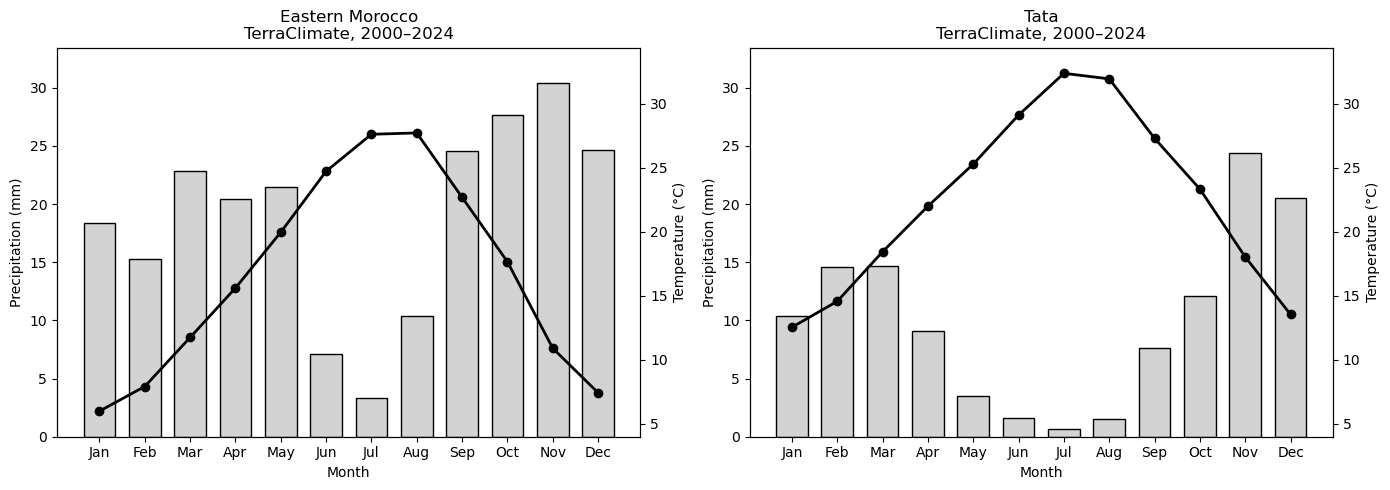

Saved: C:\Users\PangY\Python-GIS\plot\Plot_Clim\Monthly_Climate_TerraClimate_Focal_2000_2024.png


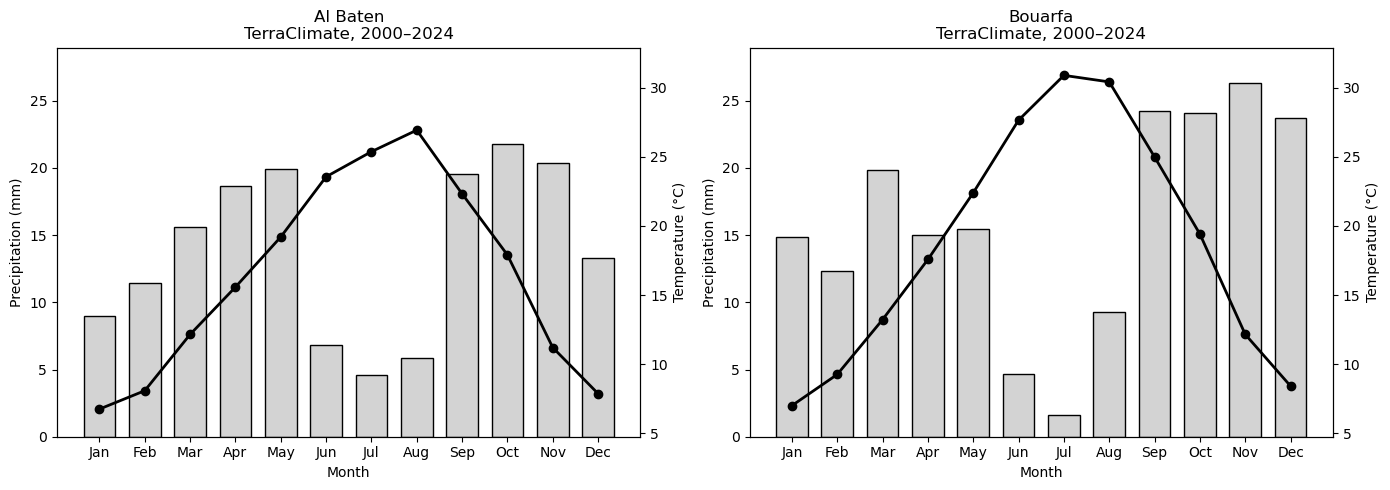

Saved: C:\Users\PangY\Python-GIS\plot\Plot_Clim\Monthly_Climate_ERA5-Land_Regional_2000_2024.png


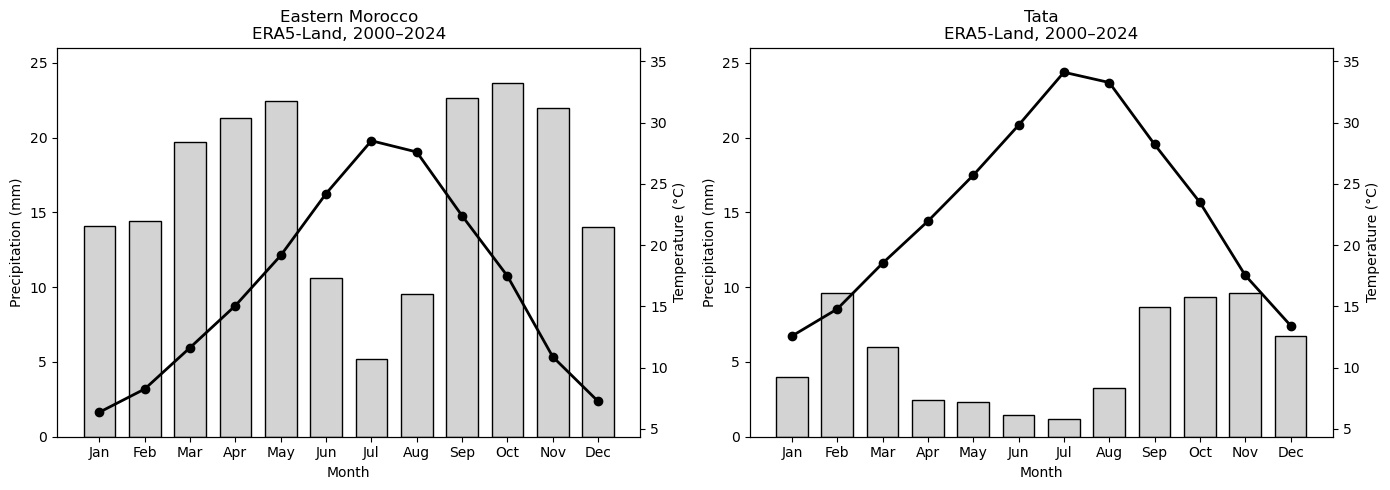

Saved: C:\Users\PangY\Python-GIS\plot\Plot_Clim\Monthly_Climate_ERA5-Land_Focal_2000_2024.png


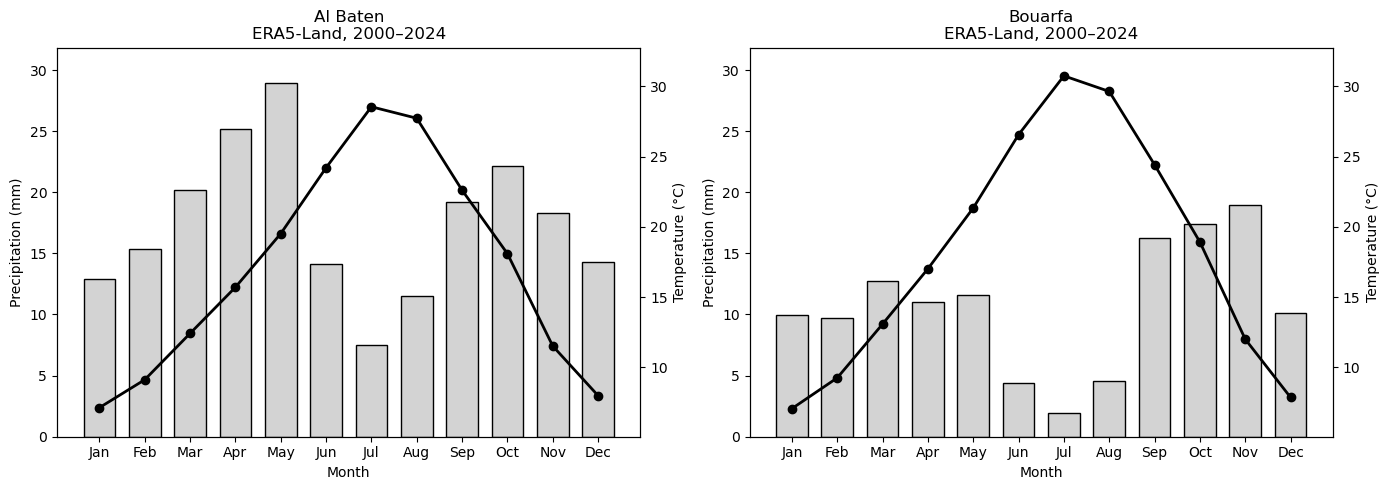

In [23]:
# TerraClimate: Regional
tc_regional_monthly = plot_monthly_climate(
    clim,
    dataset="TerraClimate",
    spatial_level="Regional",
    start_year=2000,
    end_year=2024,
    outdir=OUTDIR
)

# TerraClimate: Focal
tc_focal_monthly = plot_monthly_climate(
    clim,
    dataset="TerraClimate",
    spatial_level="Focal",
    start_year=2000,
    end_year=2024,
    outdir=OUTDIR
)

# ERA5-Land: Regional
era5_regional_monthly = plot_monthly_climate(
    clim,
    dataset="ERA5-Land",
    spatial_level="Regional",
    start_year=2000,
    end_year=2024,
    outdir=OUTDIR
)

# ERA5-Land: Focal
era5_focal_monthly = plot_monthly_climate(
    clim,
    dataset="ERA5-Land",
    spatial_level="Focal",
    start_year=2000,
    end_year=2024,
    outdir=OUTDIR
)

In [24]:
# ======================================================
# Annual climate summaries
# ======================================================

def calculate_annual_climate(
    df,
    dataset,
    spatial_level,
    year_type="calendar",
    eco_start_month=9,
    require_complete_year=True
):
    """
    Calculate annual precipitation and temperature.

    year_type:
        "calendar"   = January–December
        "ecological" = September–August

    For ecological years:
        Sep 2020 – Aug 2021 is labeled 2021.
    """

    subset = df[
        (df["dataset"] == dataset) &
        (df["spatial_level"] == spatial_level)
    ].copy()

    # -----------------------------------------------
    # Assign analysis year
    # -----------------------------------------------
    if year_type == "calendar":

        subset["analysis_year"] = subset["year"]

    elif year_type == "ecological":

        subset["analysis_year"] = np.where(
            subset["month"] >= eco_start_month,
            subset["year"] + 1,
            subset["year"]
        )

    else:
        raise ValueError(
            "year_type must be 'calendar' or 'ecological'"
        )

    # -----------------------------------------------
    # Annual aggregation
    # -----------------------------------------------
    annual = (
        subset
        .groupby(
            [
                "dataset",
                "spatial_level",
                "region",
                "analysis_year"
            ]
        )
        .agg(
            annual_precip_mm=("precip_mm", "sum"),
            annual_temp_C=("temp_C", "mean"),
            n_months=("month", "nunique")
        )
        .reset_index()
    )

    # Only retain complete 12-month years
    if require_complete_year:
        annual = annual[
            annual["n_months"] == 12
        ].copy()

    return annual

In [26]:
tc_regional_annual = calculate_annual_climate(
    clim,
    dataset="TerraClimate",
    spatial_level="Regional",
    year_type="calendar"
)

display(round(tc_regional_annual.head(),2))

,dataset,spatial_level,region,analysis_year,annual_precip_mm,annual_temp_C,n_months
0,TerraClimate,Regional,Eastern Morocco,2000,191.08,16.23,12
1,TerraClimate,Regional,Eastern Morocco,2001,177.69,16.67,12
2,TerraClimate,Regional,Eastern Morocco,2002,209.65,16.12,12
3,TerraClimate,Regional,Eastern Morocco,2003,276.89,16.44,12
4,TerraClimate,Regional,Eastern Morocco,2004,253.34,15.98,12


## 5 Wet and Dry years
**Identify wet and dry years using a 15-year baseline**

For each study area, calculate precipitation over a fixed 15-year baseline and define:

- Dry: annual precipitation ≤ baseline 25th percentile
- Normal: between 25th and 75th percentile
- Wet: annual precipitation ≥ baseline 75th percentile


This is preferable to simply saying ±20% from the mean because the thresholds are derived from the actual precipitation distribution.

In [27]:
# ======================================================
# Wet / dry year classification
# ======================================================

def classify_wet_dry_years(
    annual_df,
    baseline_start=2000,
    baseline_end=2014,
    lower_quantile=0.25,
    upper_quantile=0.75
):
    """
    Classify wet and dry years relative to a fixed baseline.

    Default baseline:
        2000–2014 = 15 years

    Classification:
        Dry    <= baseline 25th percentile
        Normal = between 25th and 75th percentile
        Wet    >= baseline 75th percentile
    """

    df = annual_df.copy()

    # -----------------------------------------------
    # Baseline data
    # -----------------------------------------------
    baseline = df[
        (df["analysis_year"] >= baseline_start) &
        (df["analysis_year"] <= baseline_end)
    ].copy()

    # -----------------------------------------------
    # Baseline statistics for each region
    # -----------------------------------------------
    baseline_stats = (
        baseline
        .groupby(
            [
                "dataset",
                "spatial_level",
                "region"
            ]
        )["annual_precip_mm"]
        .agg(
            baseline_mean="mean",
            baseline_std="std",
            dry_threshold=lambda x: x.quantile(
                lower_quantile
            ),
            wet_threshold=lambda x: x.quantile(
                upper_quantile
            )
        )
        .reset_index()
    )

    # -----------------------------------------------
    # Join thresholds back to annual data
    # -----------------------------------------------
    df = df.merge(
        baseline_stats,
        on=[
            "dataset",
            "spatial_level",
            "region"
        ],
        how="left"
    )

    # -----------------------------------------------
    # Precipitation anomalies
    # -----------------------------------------------
    df["precip_anomaly_mm"] = (
        df["annual_precip_mm"] -
        df["baseline_mean"]
    )

    df["precip_anomaly_pct"] = (
        df["precip_anomaly_mm"] /
        df["baseline_mean"] * 100
    )

    df["precip_zscore"] = (
        df["annual_precip_mm"] -
        df["baseline_mean"]
    ) / df["baseline_std"]

    # -----------------------------------------------
    # Climate classification
    # -----------------------------------------------
    df["climate_class"] = np.select(
        [
            df["annual_precip_mm"] <=
            df["dry_threshold"],

            df["annual_precip_mm"] >=
            df["wet_threshold"]
        ],
        [
            "Dry",
            "Wet"
        ],
        default="Normal"
    )

    return df, baseline_stats

### Regional Scales: Eastern Morocco vs. Tata

In [28]:
# ======================================================
# TerraClimate Regional
# Calendar-year wet/dry classification
# ======================================================

tc_regional_annual = calculate_annual_climate(
    clim,
    dataset="TerraClimate",
    spatial_level="Regional",
    year_type="calendar"
)

tc_regional_wetdry, tc_regional_baseline = classify_wet_dry_years(
    tc_regional_annual,
    baseline_start=2000,
    baseline_end=2014
)

In [29]:
display(
    tc_regional_baseline.round(1)
)

,dataset,spatial_level,region,baseline_mean,baseline_std,dry_threshold,wet_threshold
0,TerraClimate,Regional,Eastern Morocco,248.4,50.5,214.5,288.2
1,TerraClimate,Regional,Tata,141.1,52.1,98.8,174.7


In [30]:
summary_table = (
    tc_regional_wetdry[
        [
            "region",
            "analysis_year",
            "annual_precip_mm",
            "precip_anomaly_mm",
            "precip_anomaly_pct",
            "precip_zscore",
            "climate_class"
        ]
    ]
    .sort_values(
        ["region", "analysis_year"]
    )
)

display(
    summary_table.round(1)
)

,region,analysis_year,annual_precip_mm,precip_anomaly_mm,precip_anomaly_pct,precip_zscore,climate_class
0,Eastern Morocco,2000,191.1,-57.3,-23.1,-1.1,Dry
1,Eastern Morocco,2001,177.7,-70.7,-28.5,-1.4,Dry
2,Eastern Morocco,2002,209.7,-38.8,-15.6,-0.8,Dry
3,Eastern Morocco,2003,276.9,28.5,11.5,0.6,Normal
4,Eastern Morocco,2004,253.3,4.9,2.0,0.1,Normal
5,Eastern Morocco,2005,178.1,-70.4,-28.3,-1.4,Dry
6,Eastern Morocco,2006,271.5,23.1,9.3,0.5,Normal
7,Eastern Morocco,2007,231.3,-17.1,-6.9,-0.3,Normal
8,Eastern Morocco,2008,325.9,77.5,31.2,1.5,Wet
9,Eastern Morocco,2009,237.4,-11.0,-4.4,-0.2,Normal


In [31]:
wet_dry_only = (
    tc_regional_wetdry[
        tc_regional_wetdry["climate_class"]
        .isin(["Wet", "Dry"])
    ]
    [
        [
            "region",
            "analysis_year",
            "annual_precip_mm",
            "precip_anomaly_pct",
            "climate_class"
        ]
    ]
    .sort_values(
        ["region", "analysis_year"]
    )
)

display(
    wet_dry_only.round(1)
)

,region,analysis_year,annual_precip_mm,precip_anomaly_pct,climate_class
0,Eastern Morocco,2000,191.1,-23.1,Dry
1,Eastern Morocco,2001,177.7,-28.5,Dry
2,Eastern Morocco,2002,209.7,-15.6,Dry
5,Eastern Morocco,2005,178.1,-28.3,Dry
8,Eastern Morocco,2008,325.9,31.2,Wet
10,Eastern Morocco,2010,299.5,20.6,Wet
11,Eastern Morocco,2011,319.9,28.8,Wet
12,Eastern Morocco,2012,311.5,25.4,Wet
17,Eastern Morocco,2017,156.9,-36.9,Dry
18,Eastern Morocco,2018,314.6,26.6,Wet


In [32]:
wet_dry_summary = (
    tc_regional_wetdry[
        tc_regional_wetdry["climate_class"]
        .isin(["Wet", "Dry"])
    ]
    .groupby(
        ["region", "climate_class"]
    )["analysis_year"]
    .apply(
        lambda x: ", ".join(
            x.astype(str)
        )
    )
    .unstack()
    .reset_index()
)

display(wet_dry_summary)

climate_class,region,Dry,Wet
0,Eastern Morocco,"2000, 2001, 2002, 2005, 2017, 2019, 2020, 2021...","2008, 2010, 2011, 2012, 2018"
1,Tata,"2000, 2001, 2007, 2013, 2015, 2016, 2017, 2019...","2002, 2009, 2010, 2014"


### Focal Scales: AI Baten vs. Bouarfa
15 years baseline: 2000-2014

In [34]:
tc_focal_annual = calculate_annual_climate(
    clim,
    dataset="TerraClimate",
    spatial_level="Focal",
    year_type="calendar"
)

tc_focal_wetdry, tc_focal_baseline = classify_wet_dry_years(
    tc_focal_annual,
    baseline_start=2000,
    baseline_end=2014
)

display(tc_focal_baseline.round(1))

era5_regional_annual = calculate_annual_climate(
    clim,
    dataset="ERA5-Land",
    spatial_level="Regional",
    year_type="calendar"
)

era5_regional_wetdry, era5_regional_baseline = classify_wet_dry_years(
    era5_regional_annual,
    baseline_start=2000,
    baseline_end=2014
)

,dataset,spatial_level,region,baseline_mean,baseline_std,dry_threshold,wet_threshold
0,TerraClimate,Focal,Al Baten,176.6,36.2,158.7,194.2
1,TerraClimate,Focal,Bouarfa,210.9,57.0,164.2,249.7


## 6. Combined with the pre built-in module
- **`climate_analysis.py`**

In [45]:
from pathlib import Path
from climate_analysis import run_climate_analysis

BASE_DIR = Path(r"C:\Users\PangY\Python-GIS")

CLIMATE_FILE = (
    BASE_DIR
    / "csvs"
    # / "All_Climate_Areas_Monthly_2000_2025.csv"
    / "All_Climate_Areas_Monthly_1991_present.csv"
)

OUTDIR = BASE_DIR / "plots" / "Plot_Clim"

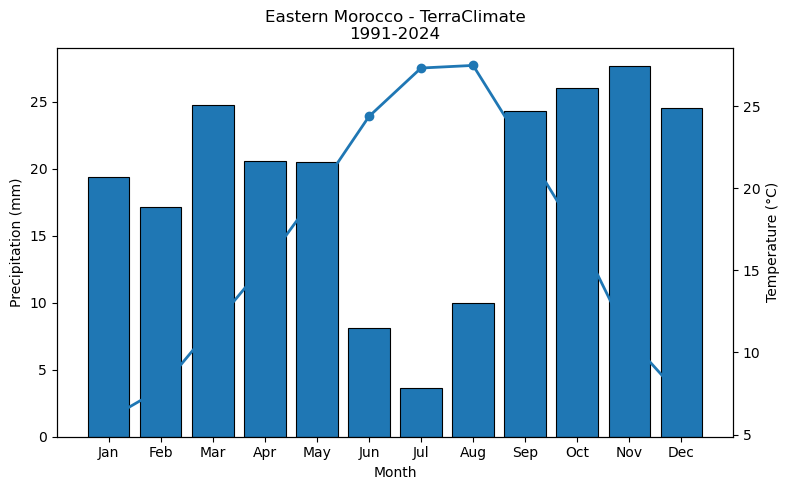

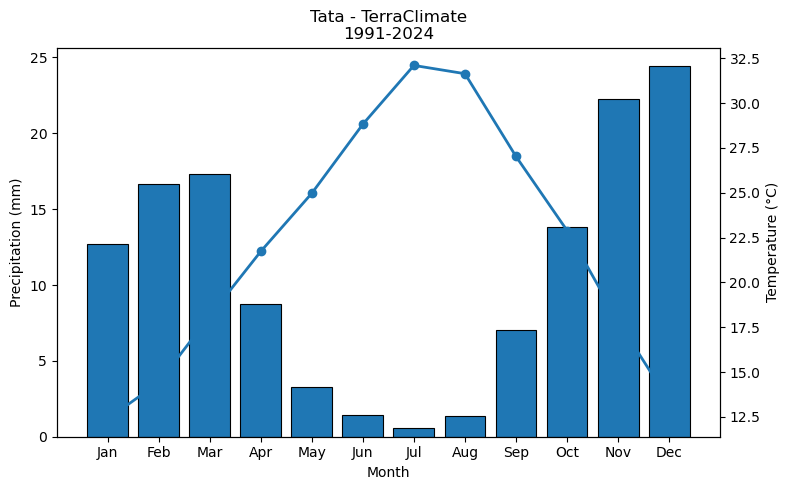

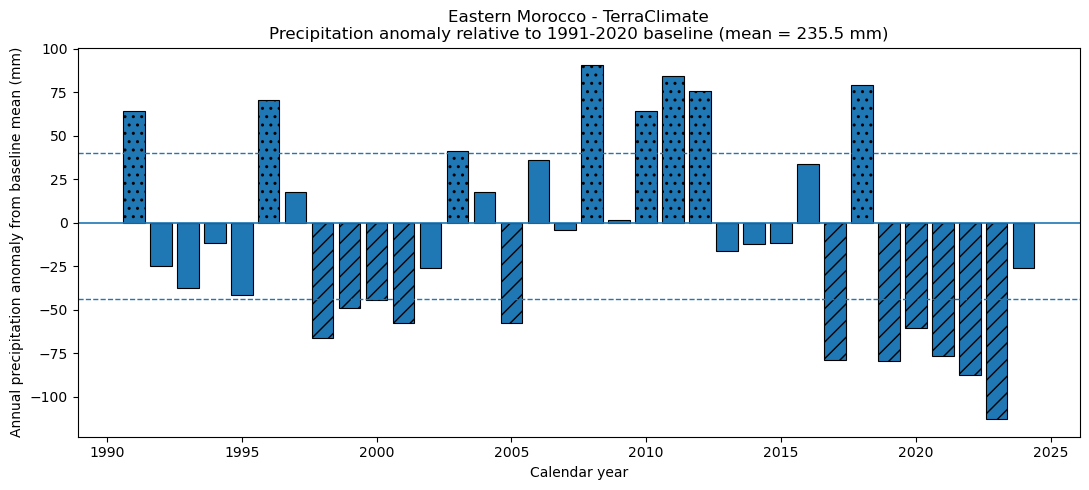

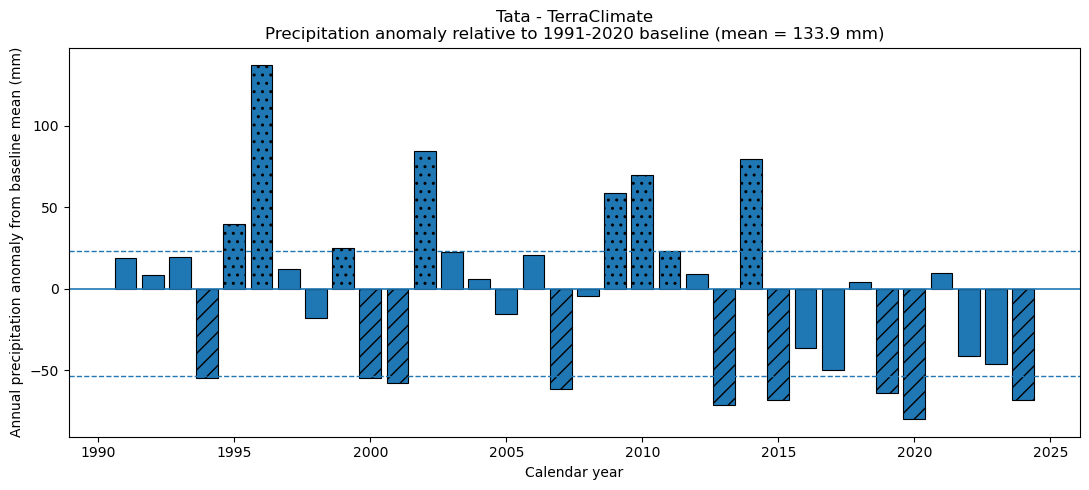

Climate analysis completed
Dataset:        TerraClimate
Spatial scale:  Regional
Analysis range: 1991-2024
Baseline:       1991-2020
Year type:      calendar

Baseline precipitation summary:
         region  baseline_n_years  baseline_mean_precip_mm  dry_threshold_mm  wet_threshold_mm
Eastern Morocco                30                    235.5             191.8             275.5
           Tata                30                    133.9              80.2             156.8

Dry and wet years:
     dataset spatial_level          region                                                              Dry                                            Wet
TerraClimate      Regional Eastern Morocco 1998, 1999, 2000, 2001, 2005, 2017, 2019, 2020, 2021, 2022, 2023 1991, 1996, 2003, 2008, 2010, 2011, 2012, 2018
TerraClimate      Regional            Tata             1994, 2000, 2001, 2007, 2013, 2015, 2019, 2020, 2024 1995, 1996, 1999, 2002, 2009, 2010, 2011, 2014

Tables:
  C:\Users\PangY\Python-GIS\pl

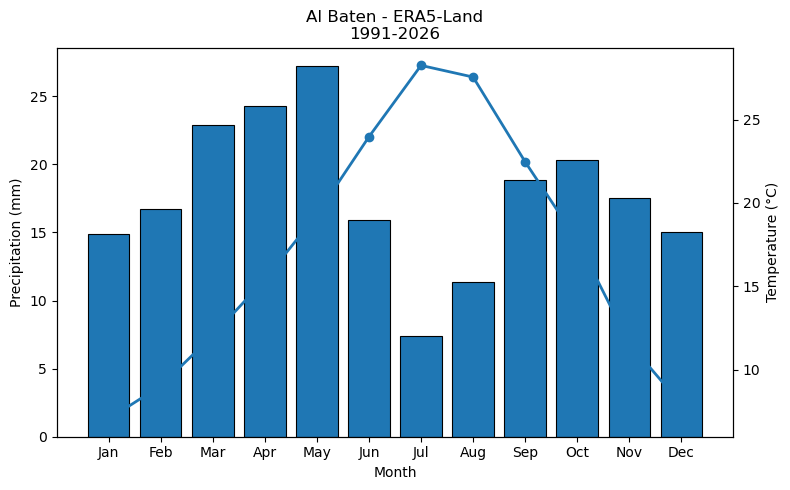

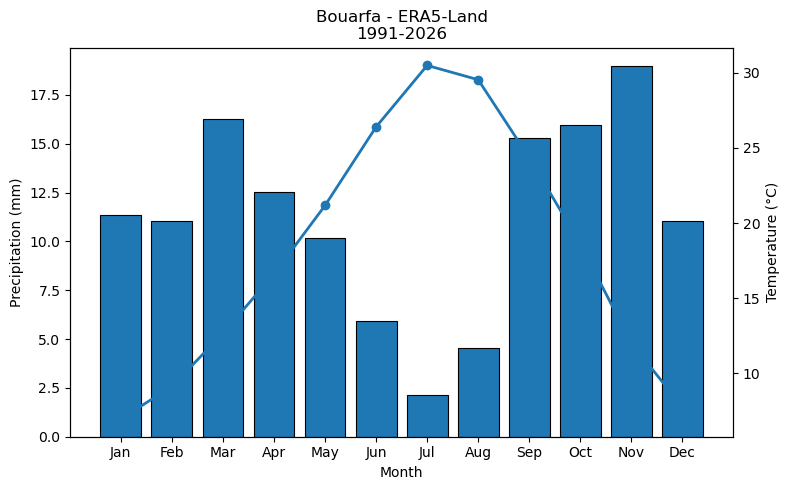

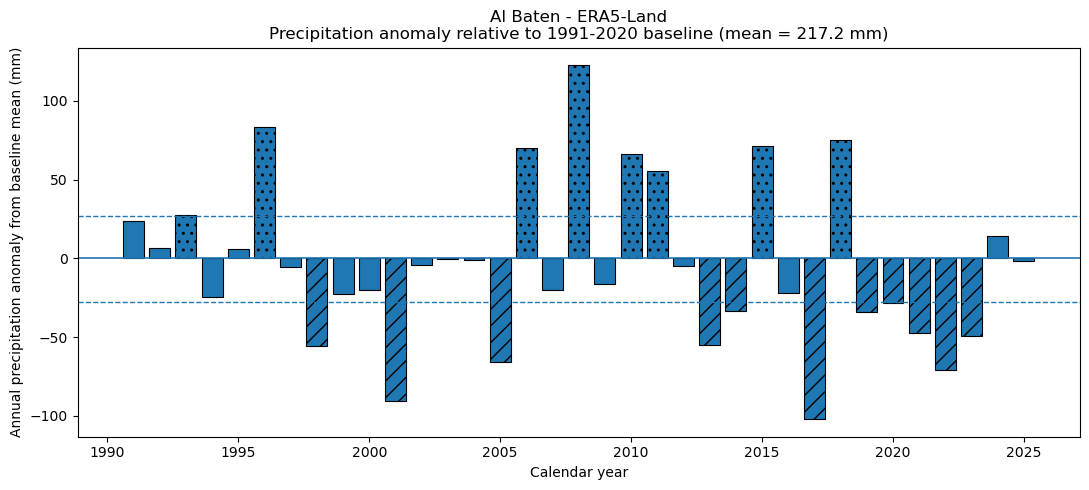

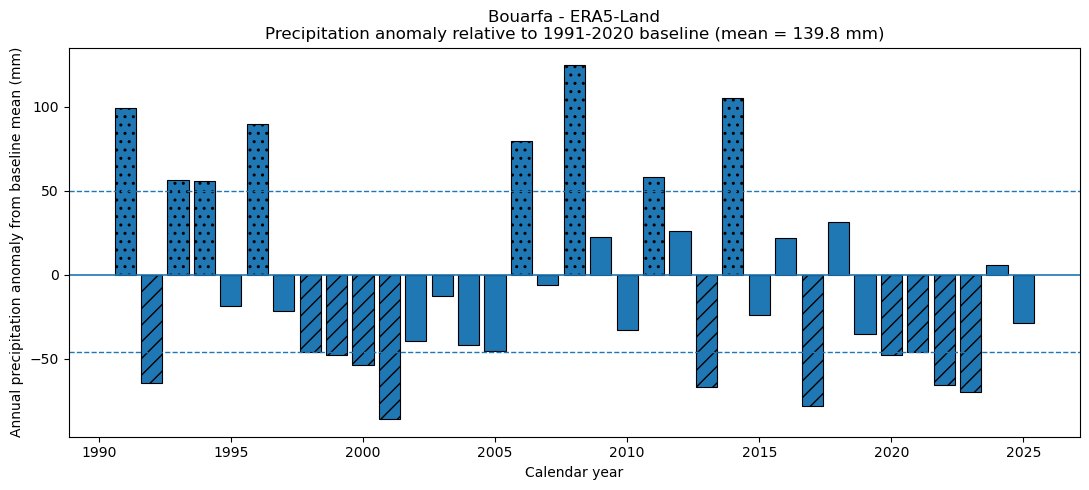

Climate analysis completed
Dataset:        ERA5-Land
Spatial scale:  Focal
Analysis range: 1991-2026
Baseline:       1991-2020
Year type:      calendar

Baseline precipitation summary:
  region  baseline_n_years  baseline_mean_precip_mm  dry_threshold_mm  wet_threshold_mm
Al Baten                30                    217.2             189.7             243.9
 Bouarfa                30                    139.8              94.0             189.3

Dry and wet years:
  dataset spatial_level   region                                                              Dry                                            Wet
ERA5-Land         Focal Al Baten 1998, 2001, 2005, 2013, 2014, 2017, 2019, 2020, 2021, 2022, 2023 1993, 1996, 2006, 2008, 2010, 2011, 2015, 2018
ERA5-Land         Focal  Bouarfa 1992, 1998, 1999, 2000, 2001, 2013, 2017, 2020, 2021, 2022, 2023 1991, 1993, 1994, 1996, 2006, 2008, 2011, 2014

Tables:
  C:\Users\PangY\Python-GIS\plot\Plot_Clim\tables\ERA5-Land_Focal_Monthly_Climatology.c

In [43]:
results1 = run_climate_analysis(
    climate_file=CLIMATE_FILE,
    outdir=OUTDIR,
    spatial_scale="Regional",
    climate_source="TerraClimate",
    baseline_start_year=1991,
    baseline_end_year=2020,
    year_type="calendar" #or year_type="ecological"
)

results2 = run_climate_analysis(
    climate_file=CLIMATE_FILE,
    outdir=OUTDIR,
    spatial_scale="Focal",
    climate_source="ERA5-Land",
    baseline_start_year=1991,
    baseline_end_year=2020,
    year_type="calendar" #or year_type="ecological"
)

Saved: C:\Users\PangY\Python-GIS\plot\Plot_Clim\figures\Monthly_Climate_TerraClimate_Regional.png


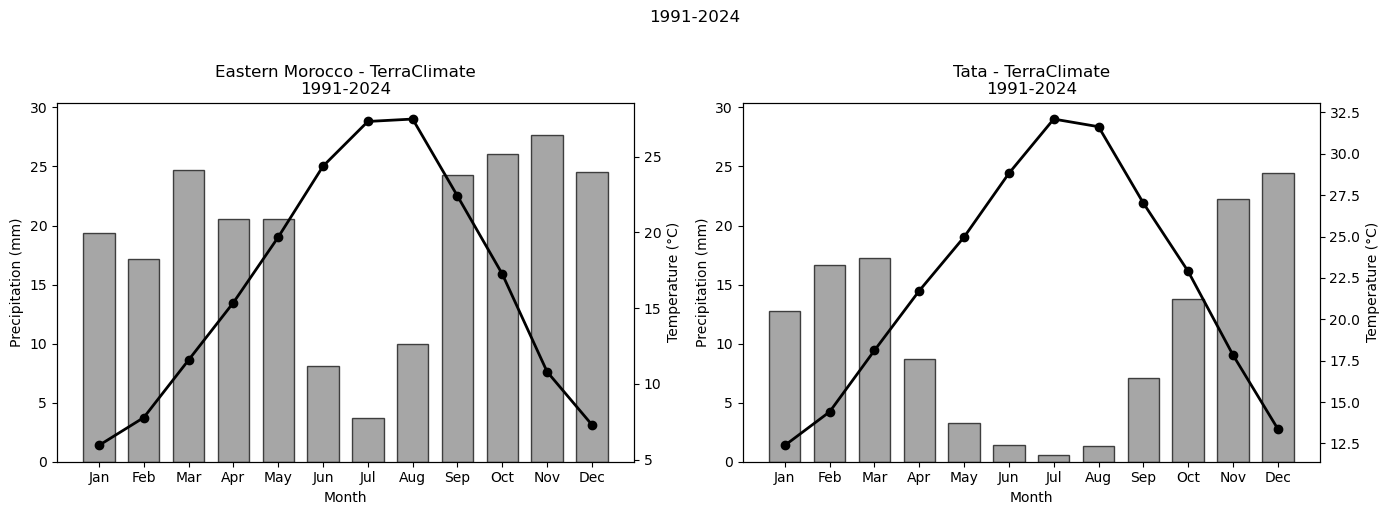

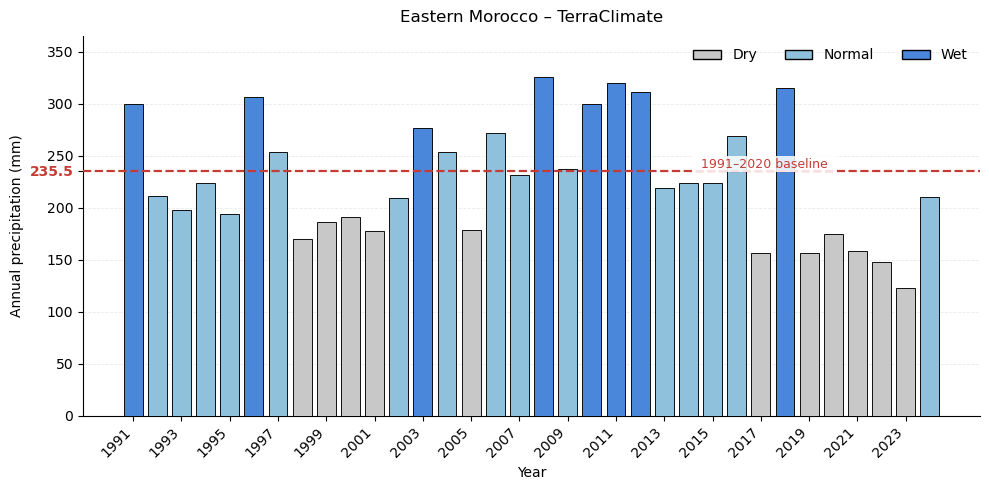

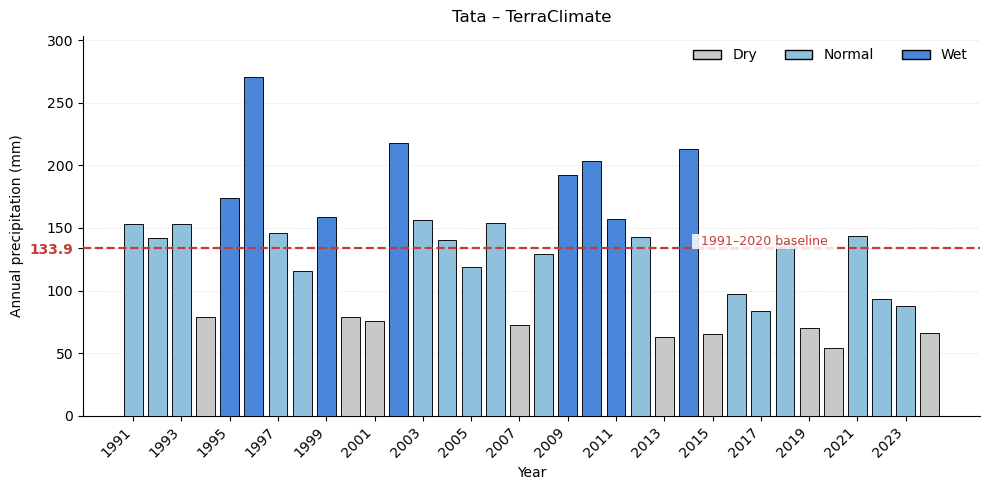

Climate analysis completed
Dataset:        TerraClimate
Spatial scale:  Regional
Analysis range: 1991-2024
Baseline:       1991-2020
Year type:      calendar

Baseline precipitation summary:
         region  baseline_n_years  baseline_mean_precip_mm  dry_threshold_mm  wet_threshold_mm
Eastern Morocco                30                    235.5             191.8             275.5
           Tata                30                    133.9              80.2             156.8

Dry and wet years:
     dataset spatial_level          region                                                              Dry                                            Wet
TerraClimate      Regional Eastern Morocco 1998, 1999, 2000, 2001, 2005, 2017, 2019, 2020, 2021, 2022, 2023 1991, 1996, 2003, 2008, 2010, 2011, 2012, 2018
TerraClimate      Regional            Tata             1994, 2000, 2001, 2007, 2013, 2015, 2019, 2020, 2024 1995, 1996, 1999, 2002, 2009, 2010, 2011, 2014

Tables:
  C:\Users\PangY\Python-GIS\pl

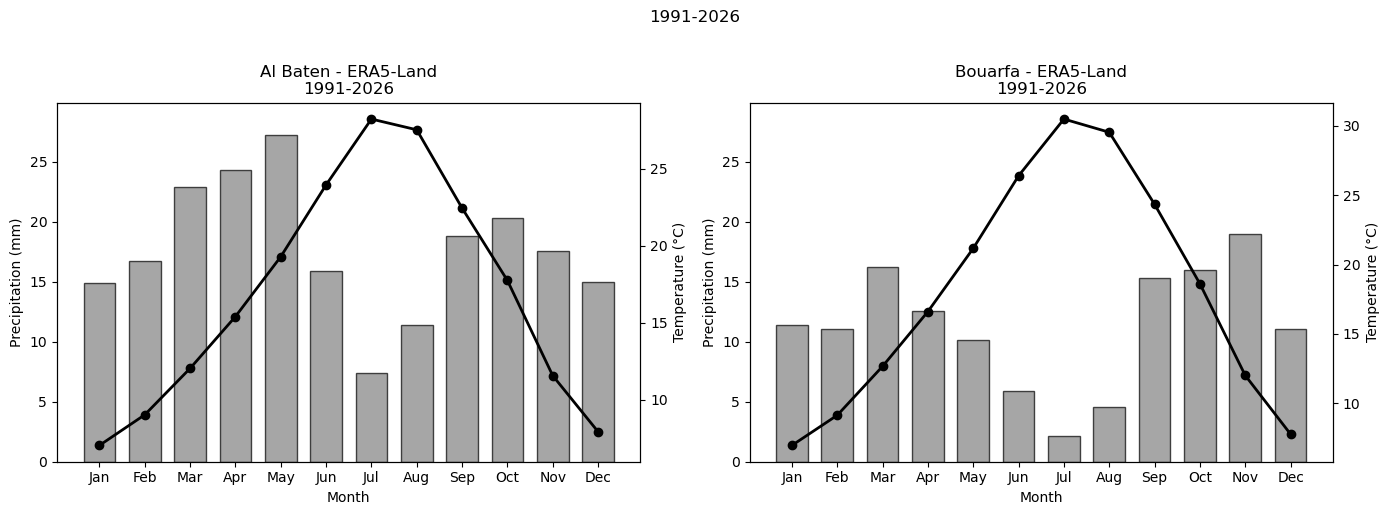

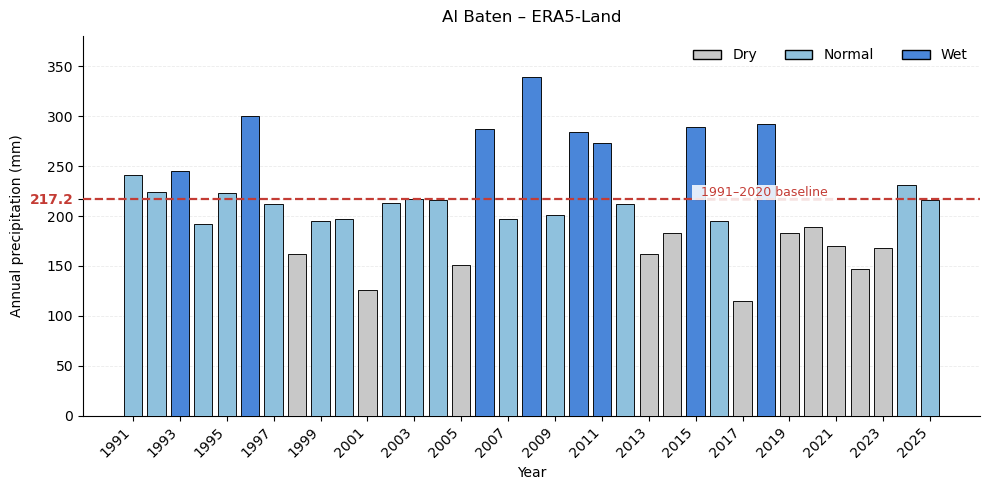

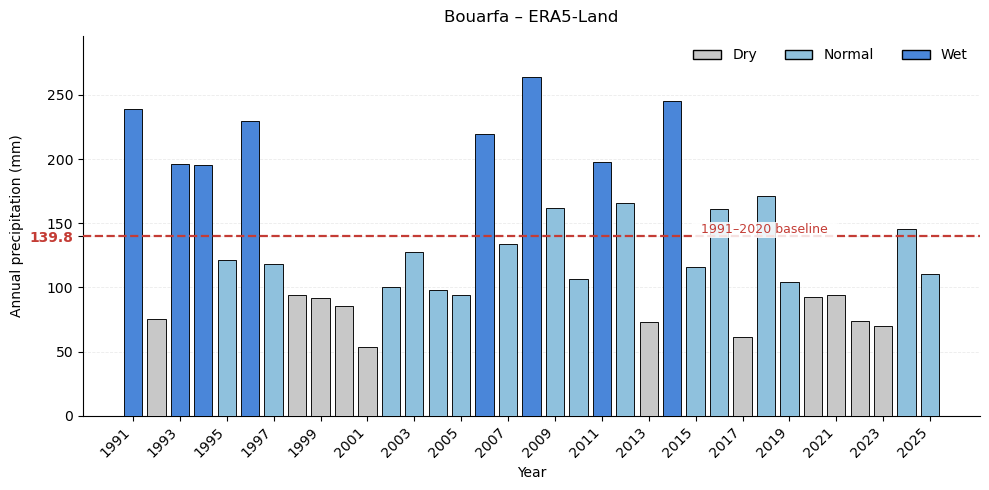

Climate analysis completed
Dataset:        ERA5-Land
Spatial scale:  Focal
Analysis range: 1991-2026
Baseline:       1991-2020
Year type:      calendar

Baseline precipitation summary:
  region  baseline_n_years  baseline_mean_precip_mm  dry_threshold_mm  wet_threshold_mm
Al Baten                30                    217.2             189.7             243.9
 Bouarfa                30                    139.8              94.0             189.3

Dry and wet years:
  dataset spatial_level   region                                                              Dry                                            Wet
ERA5-Land         Focal Al Baten 1998, 2001, 2005, 2013, 2014, 2017, 2019, 2020, 2021, 2022, 2023 1993, 1996, 2006, 2008, 2010, 2011, 2015, 2018
ERA5-Land         Focal  Bouarfa 1992, 1998, 1999, 2000, 2001, 2013, 2017, 2020, 2021, 2022, 2023 1991, 1993, 1994, 1996, 2006, 2008, 2011, 2014

Tables:
  C:\Users\PangY\Python-GIS\plot\Plot_Clim\tables\ERA5-Land_Focal_Monthly_Climatology.c

In [54]:
import climate_analysis
import importlib

importlib.reload(climate_analysis)

from climate_analysis import run_climate_analysis

results1 = run_climate_analysis(
    climate_file=CLIMATE_FILE,
    outdir=OUTDIR,
    spatial_scale="Regional",
    climate_source="TerraClimate",
    baseline_start_year=1991,
    baseline_end_year=2020,
    year_type="calendar" #or year_type="ecological"
)

results2 = run_climate_analysis(
    climate_file=CLIMATE_FILE,
    outdir=OUTDIR,
    spatial_scale="Focal",
    climate_source="ERA5-Land",
    baseline_start_year=1991,
    baseline_end_year=2020,
    year_type="calendar" #or year_type="ecological"
)